# Introducción a la Ciencia de Datos: Tarea 2

Este notebook contiene el código de base para realizar la Tarea 2 del curso. Es la continuación de la Tarea 1, por lo que se utilizarán los mismos datos y se puede reutilizar cualquier parte del código de dicha tarea.

Puede copiar este notebook en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd).

Se utiliza el lenguaje Python y las librerías Pandas y scikit-learn. Para esta tarea se recomienda consultar la sección [Extracting features from text files](https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html) de la documentación oficial de scikit-learn.

Recuerde que **se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.

## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook.

In [3]:
from time import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# from datasets import load_dataset
from src.utils import load_dataset_hf, clean_text

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# Agregue aqui el resto de las librerias que necesite

In [45]:
# Constantes 
RANDOM_STATE = 42
TEST_SIZE = 0.30
MAX_FEATURES = 20_000

# Carpeta donde se guardan las figuras para el informe
FIG_DIR = Path('figuras')
FIG_DIR.mkdir(exist_ok=True)


## Descarga del dataset
Se utilizan los mismos datos que en la Tarea 1. Ejecute la siguiente celda para descargar los datos y cargarlos en un dataframe de pandas.

In [46]:
df = load_dataset_hf()


In [47]:
df.head()

,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
0,1,1,2018-02-02,2018,2.0,2,None,BRIEF-Teva Says Fremanezumab Marketing Authori...,Feb 2 (Reuters) - Teva Pharmaceutical Industri...,https://www.reuters.com/article/brief-teva-say...,Healthcare,Reuters
1,2,2,2018-05-01,2018,5.0,1,None,CMS' Verma says it’s time health care caught u...,The head of the Centers for Medicare and Medic...,https://www.cnbc.com/2018/04/30/cms-verma-says...,Health and Science,CNBC
2,3,3,2017-08-14,2017,8.0,14,Harper Neidig,Uber investor accuses Kalanick of 'undermining...,"Benchmark, the venture capital firm that helpe...",https://thehill.com/policy/technology/346520-u...,None,The Hill
3,4,4,2017-04-03 00:00:00,2017,4.0,3,None,Chad Johnson Catches Uno Touchdown In Mexican ...,VIVA OCHOCINCO!!!!! Chad Johnson made his triu...,https://www.tmz.com/2017/04/03/chad-johnson-me...,None,TMZ
4,5,5,2018-12-27 19:20:08,2018,12.0,27,Aja Romano,"Hopepunk, explained: the storytelling trend th...",Literary and artistic movements often arise sp...,https://www.vox.com/2018/12/27/18137571/what-i...,None,Vox


# Parte 1: Dataset y representación numérica de texto

## 1. Preparación del dataset
Se utilizará un conjunto de datos reducido de los **tres medios de prensa con mayor cantidad de artículos**.
Se espera que utilice su propia versión de la función `clean_text()` de la Tarea 1.

Particione los datos para generar un conjunto de test del 30% del total, utilizando muestreo estratificado.

**Sugerencia**: utilice el parámetro `stratify` de la función `train_test_split` de scikit-learn y fije también el valor de `random_state` para obtener resultados reproducibles.

In [48]:
articles_per_pub = df['publication'].value_counts()
# print('Artículos por medio de prensa:')
# print(articles_per_pub.to_string())

top_3_publications = articles_per_pub.head(3).index
print('Top 3 medios:', top_3_publications.tolist())

df_top_3 = df[df['publication'].isin(top_3_publications)].copy()
df_top_3['publication_label'] = df_top_3['publication'].replace('The New York Times', 'NY Times')
print(f'\nDataFrame filtrado: {df_top_3.shape[0]:,} filas')
print(df_top_3['publication'].value_counts())

Top 3 medios: ['Reuters', 'The New York Times', 'CNBC']

DataFrame filtrado: 14,894 filas
publication
Reuters               9431
The New York Times    2840
CNBC                  2623
Name: count, dtype: int64


In [50]:
# Aplicar clean_text sobre el cuerpo y el título.
df_top_3 = df_top_3.copy()
df_top_3['CleanText'] = clean_text(df_top_3, 'article')
df_top_3['CleanTextTitle'] = clean_text(df_top_3, 'title')

# Verificar resultado
print('=== Texto original (primer artículo Reuters) ===')
print(df_top_3[df_top_3['publication']=='Reuters']['article'].iloc[0][:300])
print()
print('=== Texto limpio ===')
print(df_top_3[df_top_3['publication']=='Reuters']['CleanText'].iloc[0][:300])

=== Texto original (primer artículo Reuters) ===
Feb 2 (Reuters) - Teva Pharmaceutical Industries Ltd : * EUROPEAN MEDICINES AGENCY (EMA) ACCEPTS FREMANEZUMAB MARKETING AUTHORIZATION APPLICATION Source text for Eikon: Further company coverage:

=== Texto limpio ===
feb reuters teva pharmaceutical industries ltd european medicines agency ema accepts fremanezumab marketing authorization application source text for eikon further company coverage


In [51]:
# TODO: Particione los datos en train y test (30% test), con muestreo estratificado
X = df_top_3["CleanText"]
y = df_top_3["publication"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)
print(f'Train: {len(X_train):,} artículos  |  Test: {len(X_test):,} artículos')

Train: 10,425 artículos  |  Test: 4,469 artículos


## 2. Verificación del balance de clases
Genere una visualización que permita verificar que el balance de artículos de cada medio es similar en train y test.

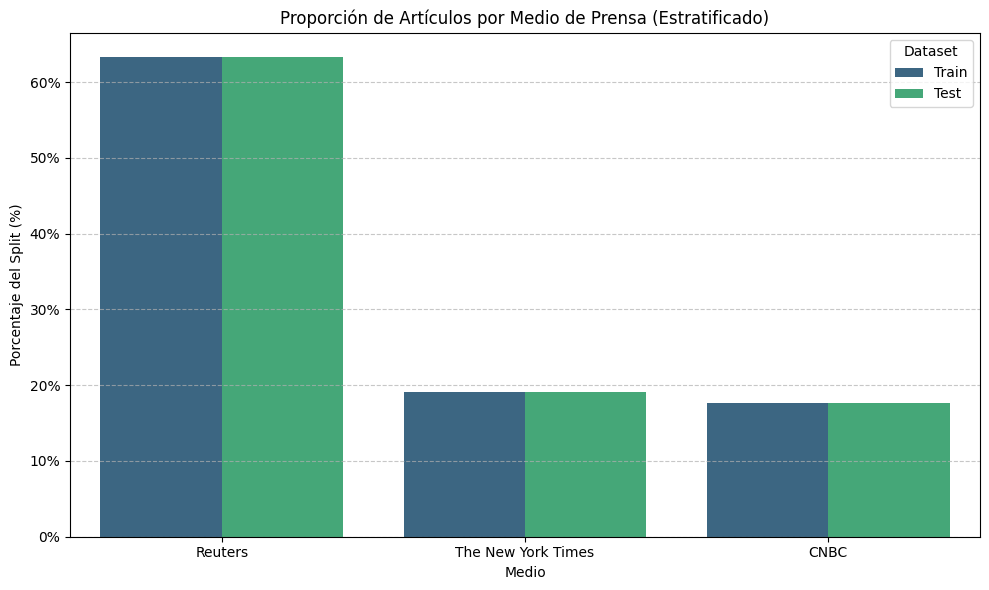

In [52]:
# TODO: Genere una visualización que muestre la proporción de artículos de cada medio
# en los conjuntos de train y test.

# 1. Calcular las proporciones relativas para cada conjunto
train_props = y_train.value_counts(normalize=True).reset_index()
train_props['Dataset'] = 'Train'

test_props = y_test.value_counts(normalize=True).reset_index()
test_props['Dataset'] = 'Test'

# 2. Combinar ambos conjuntos en un único DataFrame para graficar
df_plot = pd.concat([train_props, test_props])
df_plot.columns = ['Source', 'Proportion', 'Dataset']

# 3. Crear el gráfico de barras agrupado
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_plot, 
    x='Source', 
    y='Proportion', 
    hue='Dataset', 
    palette='viridis'
)

# 4. Formatear el eje Y como porcentaje para mejor lectura
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

plt.title('Proporción de Artículos por Medio de Prensa (Estratificado)')
plt.xlabel('Medio')
plt.ylabel('Porcentaje del Split (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(FIG_DIR / 'balance_train_test_estratificado.png', dpi=150, bbox_inches='tight')
plt.show()

Train: 10,425 articles  |  Test: 4,469 articles


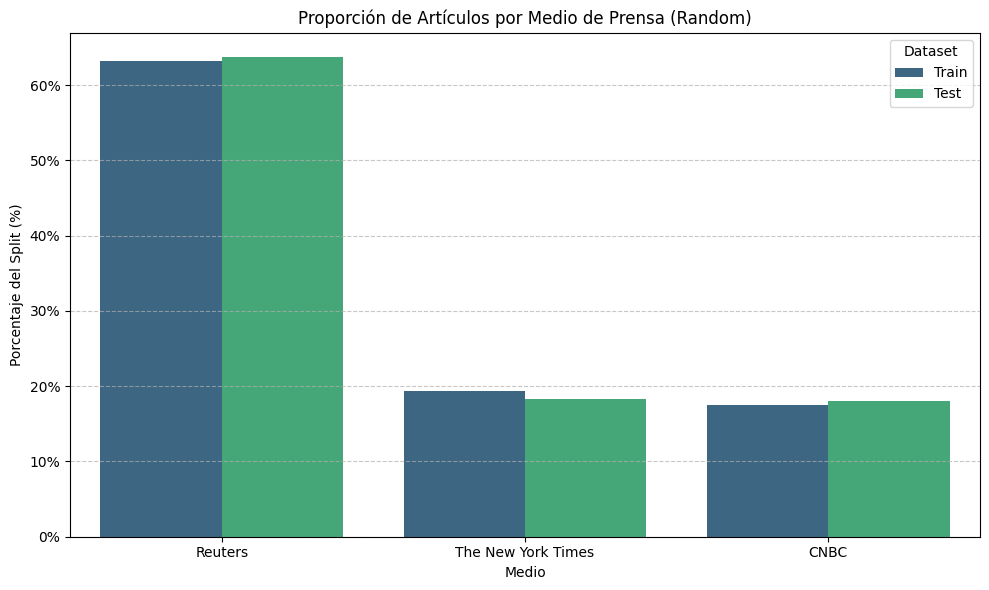

In [53]:
# =====================================================================
# Visualizacion sin stratificar
# =====================================================================

X = df_top_3["CleanText"]
y = df_top_3["publication"]

X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=None, # <--- Disables stratification
)
print(f'Train: {len(X_train_rand):,} articles  |  Test: {len(X_test_rand):,} articles')

# =====================================================================
# TODO: Genere una visualización que muestre la proporción de artículos 
# de cada medio en los conjuntos de train y test (Sin Estratificar).
# =====================================================================

# 1. Calculate relative proportions for each split
train_props_rand = y_train_rand.value_counts(normalize=True).reset_index()
train_props_rand['Dataset'] = 'Train'

test_props_rand = y_test_rand.value_counts(normalize=True).reset_index()
test_props_rand['Dataset'] = 'Test'

# 2. Combine both datasets into a single DataFrame for plotting
df_plot_rand = pd.concat([train_props_rand, test_props_rand])
df_plot_rand.columns = ['Source', 'Proportion', 'Dataset']

# 3. Create the grouped bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_plot_rand, 
    x='Source', 
    y='Proportion', 
    hue='Dataset', 
    palette='viridis'
)

# 4. Format the Y-axis as a percentage for easier reading
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

plt.title('Proporción de Artículos por Medio de Prensa (Random)')
plt.xlabel('Medio')
plt.ylabel('Porcentaje del Split (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(FIG_DIR / 'balance_train_test_aleatorio.png', dpi=150, bbox_inches='tight')
plt.show()

In [54]:
# Calculate differences for Random Split
rand_diff = abs(y_train_rand.value_counts(normalize=True) - y_test_rand.value_counts(normalize=True))
print(f"Max discrepancy without stratification: {rand_diff.max():.4%}")

# Calculate differences for Stratified Split
strat_diff = abs(y_train.value_counts(normalize=True) - y_test.value_counts(normalize=True))
print(f"Max discrepancy with stratification: {strat_diff.max():.4%}")

Max discrepancy without stratification: 1.1877%
Max discrepancy with stratification: 0.0062%


En este análisis, la discrepancia máxima mide la diferencia más crítica que hay entre las estructuras de los conjuntos de train y test. Específicamente, lo que hace es calcular el porcentaje que representa cada medio en ambos conjuntos, restar esos valores para ver la distancia absoluta y quedarse con la diferencia más grande que encuentre.
- El resultado de 1.19% (Partición Aleatoria): Nos indica que el medio más afectado varía apenas un punto porcentual entre un conjunto y el otro. Esto demuestra que, si bien el muestreo aleatorio es bastante representativo gracias al volumen de datos, igual introduce un mínimo ruido por puro azar.
- El resultado de 0.01% (Partición Estratificada): Comprueba que al forzar la estratificación se elimina matemáticamente esa variabilidad, logrando que la distribución de los medios sea prácticamente idéntica en ambos lados. 

Estas diferencias se pueden observar en la gráfica de Proporción de artículos publicados por medio de prensa. En la Figura sin estratificar vemos una clara aunque pequeña diferencia entre train y test, mientras que estratificado vemos una proporción virtualmente idéntica entre train y test.

## 3. Representación Bag of Words
Transforme el texto del conjunto de entrenamiento a una representación numérica (features) de conteo de palabras (*bag of words*).
Explique brevemente cómo funciona esta técnica y muestre un ejemplo.
En particular, explique el tamaño de la matriz resultante y la razón por la que es una matriz *sparse*.

**Sugerencia**: puede ser útil imaginar qué sucedería con la memoria RAM requerida si no estuviéramos trabajando con un conjunto de datos reducido.

Vocabulario completo del train: 82,731 palabras

  top-k features |  cobertura ocurrencias
------------------------------------------
           5,000 |                86.89%
          10,000 |                92.54%
          20,000 |                96.35%
          30,000 |                97.88%
          50,000 |                99.18%

MAX_FEATURES=20,000 equivale a conservar términos con frecuencia total >= 9

Palabras en 1 solo documento : 38,418 (46.4% del vocabulario)
Palabras en <= 5 documentos  : 60,308 (72.9% del vocabulario)

Tamaño del vocabulario según min_df:
  min_df= 1 -> 82,731 palabras
  min_df= 2 -> 44,313 palabras
  min_df= 5 -> 25,025 palabras
  min_df=10 -> 16,437 palabras


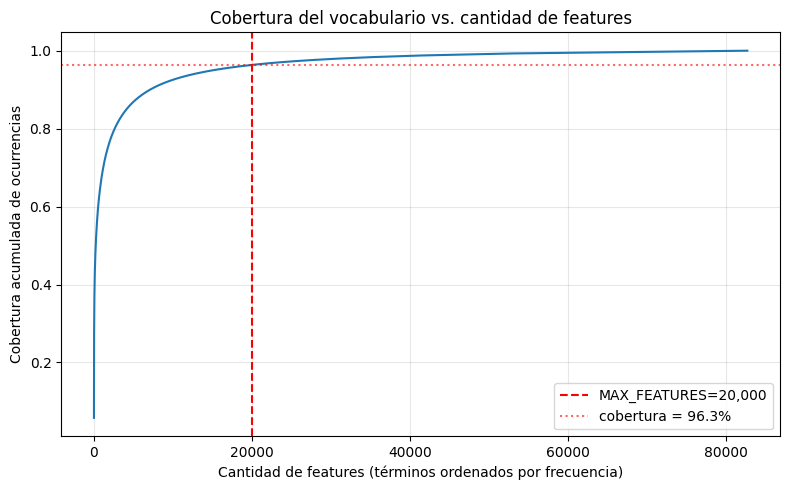

In [55]:
# --- ¿Cuántas features conviene conservar? Análisis de cobertura del vocabulario ---
# Antes de fijar MAX_FEATURES, vemos el tamaño real del vocabulario y cuánta información
# (ocurrencias) se conserva al recortar a los términos más frecuentes.
cv_full = CountVectorizer()
X_full = cv_full.fit_transform(X_train)
vocab_full = X_full.shape[1]

term_counts = np.asarray(X_full.sum(axis=0)).ravel()    # frecuencia TOTAL de cada término
doc_freq = np.asarray((X_full > 0).sum(axis=0)).ravel()  # en cuántos documentos aparece (df)
total_tokens = term_counts.sum()

# Cobertura acumulada: qué % de las ocurrencias cubren los top-k términos más frecuentes
order = np.argsort(term_counts)[::-1]
cum_coverage = np.cumsum(term_counts[order]) / total_tokens

print(f'Vocabulario completo del train: {vocab_full:,} palabras\n')
print(f'{"top-k features":>16} | {"cobertura ocurrencias":>22}')
print('-' * 42)
for k in [5_000, 10_000, 20_000, 30_000, 50_000]:
    if k <= vocab_full:
        print(f'{k:>16,} | {cum_coverage[k-1]:>21.2%}')

# MAX_FEATURES se traduce en un umbral de frecuencia total
thr = np.sort(term_counts)[::-1][MAX_FEATURES - 1]
print(f'\nMAX_FEATURES={MAX_FEATURES:,} equivale a conservar términos con frecuencia total >= {thr}')

# La cola larga: palabras muy raras (df bajo)
print(f'\nPalabras en 1 solo documento : {(doc_freq <= 1).sum():,} ({(doc_freq <= 1).mean():.1%} del vocabulario)')
print(f'Palabras en <= 5 documentos  : {(doc_freq <= 5).sum():,} ({(doc_freq <= 5).mean():.1%} del vocabulario)')

# Alternativa más interpretable: filtrar por frecuencia documental (min_df)
print('\nTamaño del vocabulario según min_df:')
for md in [1, 2, 5, 10]:
    v = CountVectorizer(min_df=md).fit_transform(X_train).shape[1]
    print(f'  min_df={md:>2} -> {v:,} palabras')

# Curva de cobertura acumulada
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, vocab_full + 1), cum_coverage)
plt.axvline(MAX_FEATURES, color='red', linestyle='--', label=f'MAX_FEATURES={MAX_FEATURES:,}')
plt.axhline(cum_coverage[MAX_FEATURES - 1], color='red', linestyle=':', alpha=0.6,
            label=f'cobertura = {cum_coverage[MAX_FEATURES - 1]:.1%}')
plt.xlabel('Cantidad de features (términos ordenados por frecuencia)')
plt.ylabel('Cobertura acumulada de ocurrencias')
plt.title('Cobertura del vocabulario vs. cantidad de features')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cobertura_vocabulario.png', dpi=150, bbox_inches='tight')
plt.show()


In [56]:
# Transforme el texto de entrenamiento a una representación Bag of Words (conteo de palabras).
# CountVectorizer hace tokenización + conteo y devuelve una matriz dispersa (scipy CSR).
count_vectorizer = CountVectorizer(max_features=MAX_FEATURES)
X_train_counts = count_vectorizer.fit_transform(X_train)

# --- Tamaño de la matriz resultante ---
n_docs, n_vocab = X_train_counts.shape
print(f'Matriz Bag of Words: {n_docs:,} documentos x {n_vocab:,} palabras (vocabulario)')
print(f'Tipo de objeto      : {type(X_train_counts)}')

# --- ¿Por qué es sparse? Densidad y memoria ---
n_nonzero = X_train_counts.nnz
n_cells = n_docs * n_vocab
density = n_nonzero / n_cells
print(f'\nCeldas totales      : {n_cells:,}')
print(f'Celdas no nulas     : {n_nonzero:,}')
print(f'Densidad            : {density:.4%}  (es decir, {1 - density:.2%} de la matriz son ceros)')

# Memoria: representación dispersa vs. densa (int64 = 8 bytes por celda)
mem_sparse_mb = (X_train_counts.data.nbytes + X_train_counts.indices.nbytes + X_train_counts.indptr.nbytes) / 1024**2
mem_dense_mb = n_cells * 8 / 1024**2
print(f'\nMemoria (dispersa)  : {mem_sparse_mb:,.1f} MB')
print(f'Memoria (densa)     : {mem_dense_mb:,.1f} MB  -> {mem_dense_mb / mem_sparse_mb:,.0f}x mas')

# --- Ejemplo: conteos de un documento concreto ---
vocab = count_vectorizer.get_feature_names_out()
doc_idx = 0
row = X_train_counts[doc_idx].toarray().ravel()
present = np.argsort(row)[::-1][:10]  # 10 palabras con mayor conteo en el documento
print(f'\n=== Ejemplo: palabras mas frecuentes en el documento #{doc_idx} ===')
for j in present:
    if row[j] > 0:
        print(f'  {vocab[j]:<20} -> {row[j]}')


Matriz Bag of Words: 10,425 documentos x 20,000 palabras (vocabulario)
Tipo de objeto      : <class 'scipy.sparse._csr.csr_matrix'>

Celdas totales      : 208,500,000
Celdas no nulas     : 2,011,506
Densidad            : 0.9648%  (es decir, 99.04% de la matriz son ceros)

Memoria (dispersa)  : 23.1 MB
Memoria (densa)     : 1,590.7 MB  -> 69x mas

=== Ejemplo: palabras mas frecuentes en el documento #0 ===
  the                  -> 18
  in                   -> 10
  and                  -> 10
  to                   -> 7
  investigation        -> 7
  maersk               -> 6
  container            -> 6
  an                   -> 5
  had                  -> 5
  by                   -> 5


### Bag of Words con `CountVectorizer`

*Bag of Words* (BOW) convierte cada texto en un vector numérico: a partir de un **vocabulario** (las palabras distintas del corpus) se crea un atributo por palabra, y cada documento se representa por las **ocurrencias** de esas palabras, **ignorando el orden** [1, 2]. Acá usamos el valor de **conteo** (cantidad de ocurrencias).

`CountVectorizer` hace **tokenización + conteo** y devuelve **conteos crudos** (enteros).

**Tamaño y *sparsity*.** La matriz es **`n_documentos × |vocabulario|`** (acotada por `MAX_FEATURES = 20.000`). Es **dispersa** porque cada documento usa solo un pequeño subconjunto del vocabulario, así que casi todas las celdas son 0: según scikit-learn, *"típicamente más del 99%"* de los valores son cero [1]. Por eso se guarda en formato disperso (`scipy.sparse` / CSR), que almacena solo los valores no nulos y sus posiciones, lo que permite *"almacenar la matriz en memoria y acelerar las operaciones algebraicas"* [1].

**Costo en memoria.** Con nuestro conjunto reducido (3 medios), la matriz densa ocuparía ≈ **1,5 GB** (10.425 × 20.000 enteros): entra en RAM, pero ya son decenas de veces más que la versión dispersa, y la inmensa mayoría son ceros. El problema **escala muy mal**: si usáramos los **26 medios** del dataset completo (30.072 artículos × 150.546 términos de vocabulario, sin recortar), la matriz densa sería de ≈ **34 GB** —inviable en una RAM típica de 8–16 GB—, mientras que su versión dispersa ocupa apenas ≈ **79 MB** (≈ 435× menos, con una densidad de solo 0,15%).

---
**Referencias**

[1] scikit-learn, *Text feature extraction* / `CountVectorizer`. https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction

[2] C. D. Manning, P. Raghavan y H. Schütze, *Introduction to Information Retrieval*, Cambridge University Press, 2008. https://nlp.stanford.edu/IR-book/


## 4. Representación TF-IDF
Explique brevemente qué es un **n-grama**.
Obtenga la representación numérica *Term Frequency - Inverse Document Frequency* (TF-IDF).
Explique brevemente en qué consiste esta transformación adicional.

In [57]:
# Representación TF-IDF del conjunto de entrenamiento.
# TfidfVectorizer = CountVectorizer (tokeniza + cuenta) + ponderación TF-IDF + normalización L2.
tfidf_vectorizer = TfidfVectorizer(max_features=MAX_FEATURES)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

print(f'Matriz TF-IDF: {X_train_tfidf.shape[0]:,} documentos x {X_train_tfidf.shape[1]:,} términos')
print(f'Tipo: {type(X_train_tfidf).__name__}  |  dtype: {X_train_tfidf.dtype}')

# Ejemplo: términos con mayor peso TF-IDF en un documento concreto
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()
doc_idx = 0
row = X_train_tfidf[doc_idx].toarray().ravel()
top = np.argsort(row)[::-1][:10]
print(f'\n=== Términos con mayor TF-IDF en el documento #{doc_idx} ===')
for j in top:
    if row[j] > 0:
        print(f'  {vocab_tfidf[j]:<20} -> {row[j]:.4f}')


Matriz TF-IDF: 10,425 documentos x 20,000 términos
Tipo: csr_matrix  |  dtype: float64

=== Términos con mayor TF-IDF en el documento #0 ===
  maersk               -> 0.4327
  container            -> 0.3950
  investigation        -> 0.2518
  msc                  -> 0.2303
  doj                  -> 0.2004
  shipping             -> 0.1999
  the                  -> 0.1946
  lloyd                -> 0.1815
  fines                -> 0.1120
  antitrust            -> 0.1100


### n-gramas y TF-IDF

**n-grama.** Un *n-grama* es una secuencia de **n palabras consecutivas**. El BOW básico usa *unigramas* (n = 1) y por eso ignora por completo el orden; tomar *bigramas* (n = 2, pares de palabras seguidas) o trigramas permite capturar frases y algo de orden local. A este enfoque se lo llama *bag-of-n-grams* [1, 3]. Como dice scikit-learn, *"una colección de unigramas no puede capturar frases ni expresiones multipalabra... en lugar de una colección de unigramas (n=1), podríamos preferir una de bigramas (n=2), donde se cuentan las ocurrencias de pares de palabras consecutivas"* [1]. En `CountVectorizer`/`TfidfVectorizer` se controla con el parámetro `ngram_range` (p. ej. `ngram_range=(1,2)` toma unigramas **y** bigramas). El costo es que el vocabulario —y por lo tanto la dimensionalidad— crece mucho.

**TF-IDF (*Term Frequency – Inverse Document Frequency*).** Es una **ponderación** que reemplaza el conteo crudo por un peso que indica qué tan *informativo* es cada término: alto si la palabra es frecuente en el documento pero **rara en el corpus**, y bajo si aparece en casi todos los documentos (como las *stopwords*, que dejan de dominar) [1, 2]. Combina dos factores:

- **TF** (*term frequency*): cuántas veces aparece el término en el documento.
- **IDF** (*inverse document frequency*): en la formulación clásica, $idf(t) = \log\frac{N}{df(t)}$, con $N$ = nº de documentos y $df(t)$ = nº de documentos donde aparece $t$ [2].
- **tf-idf = tf × idf**.

> **Implementación.** `TfidfVectorizer` no usa exactamente esa fórmula. Por defecto aplica un IDF *suavizado*, $idf(t) = \ln\frac{1+N}{1+df(t)} + 1$, y **normaliza cada vector-documento por su norma L2** (`norm='l2'`): lo divide por su propio largo para que todos midan 1, haciendo comparables documentos de distinto tamaño [1]. Es decir, `TfidfVectorizer` ≈ `CountVectorizer` (tokeniza + cuenta) **+** esta ponderación y normalización.

---
**Referencias**

[1] scikit-learn, *Text feature extraction* (n-grams y TF-IDF term weighting). https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction

[2] C. D. Manning, P. Raghavan y H. Schütze, *Introduction to Information Retrieval*, Cambridge University Press, 2008, cap. 6 (*tf-idf weighting*). https://nlp.stanford.edu/IR-book/

[3] D. Jurafsky y J. H. Martin, *Speech and Language Processing* (3.ª ed., borrador), cap. de semántica vectorial / *bag of words* y n-gramas. https://web.stanford.edu/~jurafsky/slp3/


## 5. Visualización PCA sobre TF-IDF
Muestre en un mapa el conjunto de entrenamiento, utilizando las dos primeras componentes PCA sobre los vectores de TF-IDF.
Analice los resultados y compare qué sucede si utiliza:
- a) el filtrado de `stop_words` para idioma inglés;
- b) el parámetro `use_idf=True`;
- c) `ngram_range=(1,2)`.

Opcionalmente, también puede analizar qué sucede si no elimina los signos de puntuación.

¿Se pueden separar los medios de prensa utilizando sólo 2 componentes principales?
Haga una visualización que permita entender cómo varía la varianza explicada a medida que se agregan componentes (por ejemplo, hasta 10 componentes).

Discuta además si la separación observada puede deberse a diferencias de estilo editorial, a diferencias temáticas o a pistas explícitas del medio que no hayan sido removidas en la limpieza.

### Introducción: reducción de dimensionalidad y PCA

Las representaciones BOW y TF-IDF ubican cada artículo en un espacio de **altísima dimensión** (hasta `MAX_FEATURES = 20.000` atributos, uno por palabra). En esa dimensión es imposible visualizar los datos y, además, la mayoría de los ejes aportan poca información (ya que casi todo son ceros). La **reducción de dimensionalidad** busca describir los mismos datos con muchas menos variables, perdiendo la menor cantidad de información posible.

El **Análisis de Componentes Principales (PCA)** es la técnica lineal clásica para esto [1]. Pensando cada documento como un punto en $\mathbb{R}^K$ (la *nube de individuos*), PCA busca un nuevo sistema de ejes —las **componentes principales**— que representen la nube en pocas dimensiones **distorsionando lo menos posible las distancias** entre los puntos. El resultado central es que esa representación óptima coincide con la de **máxima varianza**: 

- La **1ª componente (PC1)** es la dirección a lo largo de la cual los datos más varían.
- La **2ª componente (PC2)** es la dirección de máxima varianza **ortogonal** a la primera, y así sucesivamente.

Matemáticamente, las componentes son los **vectores propios de la matriz de covarianzas** $S = \tfrac{1}{I}X^\top X$ (con $X$ centrada), y sus **valores propios** $\lambda_1 \ge \lambda_2 \ge \dots$ indican cuánta varianza captura cada una [1]. Proyectando sobre las primeras componentes obtenemos las nuevas coordenadas; la **varianza explicada** por las primeras $n$ componentes, $\frac{\lambda_1 + \dots + \lambda_n}{\lambda_1 + \dots + \lambda_K}$, mide la **calidad de la representación**.

En esta sección aplicamos PCA sobre los vectores **TF-IDF** del conjunto de entrenamiento para:
1. Proyectar los artículos a las **2 primeras componentes** y graficarlos coloreados por medio de prensa, evaluando si los tres medios se **separan** en ese plano.
2. Analizar cómo cambia esa separación con distintas configuraciones del `TfidfVectorizer` (`stop_words`, `use_idf`, `ngram_range`).
3. Estudiar la **varianza explicada acumulada** al incorporar más componentes, para entender cuánta información se conserva al reducir a tan pocas dimensiones.

---
**Referencias**

[1] M. I. Fariello (basado en diapositivas de M. Carrasco), *Reducción de dimensionalidad* (PCA), Introducción a la Ciencia de Datos, IMERL – Facultad de Ingeniería, UdelaR, 2025.

[2] scikit-learn, `sklearn.decomposition.PCA`. https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html


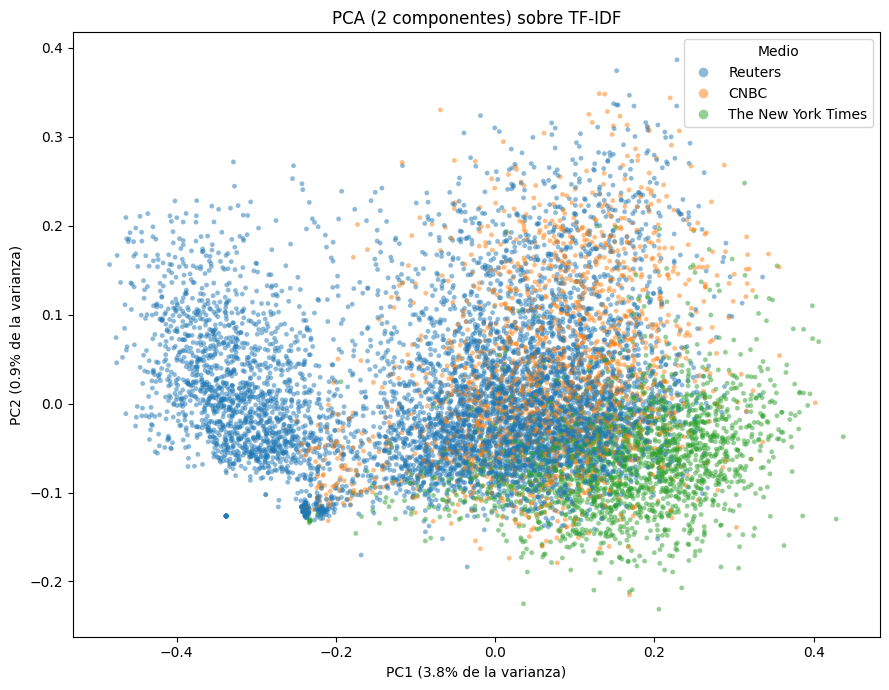

Varianza explicada por las 2 primeras componentes: 4.75%


In [58]:
# PCA con 2 componentes sobre los vectores TF-IDF, coloreado por medio de prensa.
# PCA centra los datos -> requiere matriz densa. Con este conjunto reducido densificar
# es viable (~1,5 GB); para un dataset grande se usaría TruncatedSVD (no centra, admite sparse).
X_train_tfidf_dense = X_train_tfidf.toarray()

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_train_tfidf_dense)

plt.figure(figsize=(9, 7))
sns.scatterplot(
    x=coords[:, 0], y=coords[:, 1],
    hue=y_train.values, s=12, alpha=0.5, edgecolor='none', #palette='viridis'
)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} de la varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} de la varianza)')
plt.title('PCA (2 componentes) sobre TF-IDF')
plt.legend(title='Medio', markerscale=2)
plt.tight_layout()
plt.savefig(FIG_DIR / 'pca_tfidf_2comp.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Varianza explicada por las 2 primeras componentes: '
      f'{pca.explained_variance_ratio_[:2].sum():.2%}')


#### Análisis — ¿se separan los medios en el plano de 2 componentes?

En el plano de las dos primeras componentes principales **los tres medios no forman grupos nítidamente separados**. Existe una amplia **región central de solapamiento** donde conviven **Reuters (azul)**, **CNBC (naranja)** y **NY Times (verde)**. Reuters muestra una zona parcialmente propia y, de hecho, aparece en **dos sub-regiones**: una algo más diferenciada y otra que se mezcla con CNBC y NY Times —lo que sugiere sub-grupos temáticos dentro del mismo medio.

Esta falta de separación se explica por dos motivos de fondo:

- **PCA es no supervisado**: busca las direcciones de **máxima varianza total**, no las que mejor separan los medios. No usa las etiquetas, así que aunque las clases fueran separables, no necesariamente lo evidenciaría.
- Las dos componentes **explican muy poca varianza** (≈ 4–5 %, ver más abajo): el plano 2D es una proyección muy pobre de un espacio de ~20.000 dimensiones.

**Conclusión:** con solo 2 componentes principales **no** se pueden separar los medios de forma clara. Pero esto **no implica que sean inseparables**: refleja sobre todo que PCA no optimiza la separación entre clases y que en 2D se conserva una fracción mínima de la información.


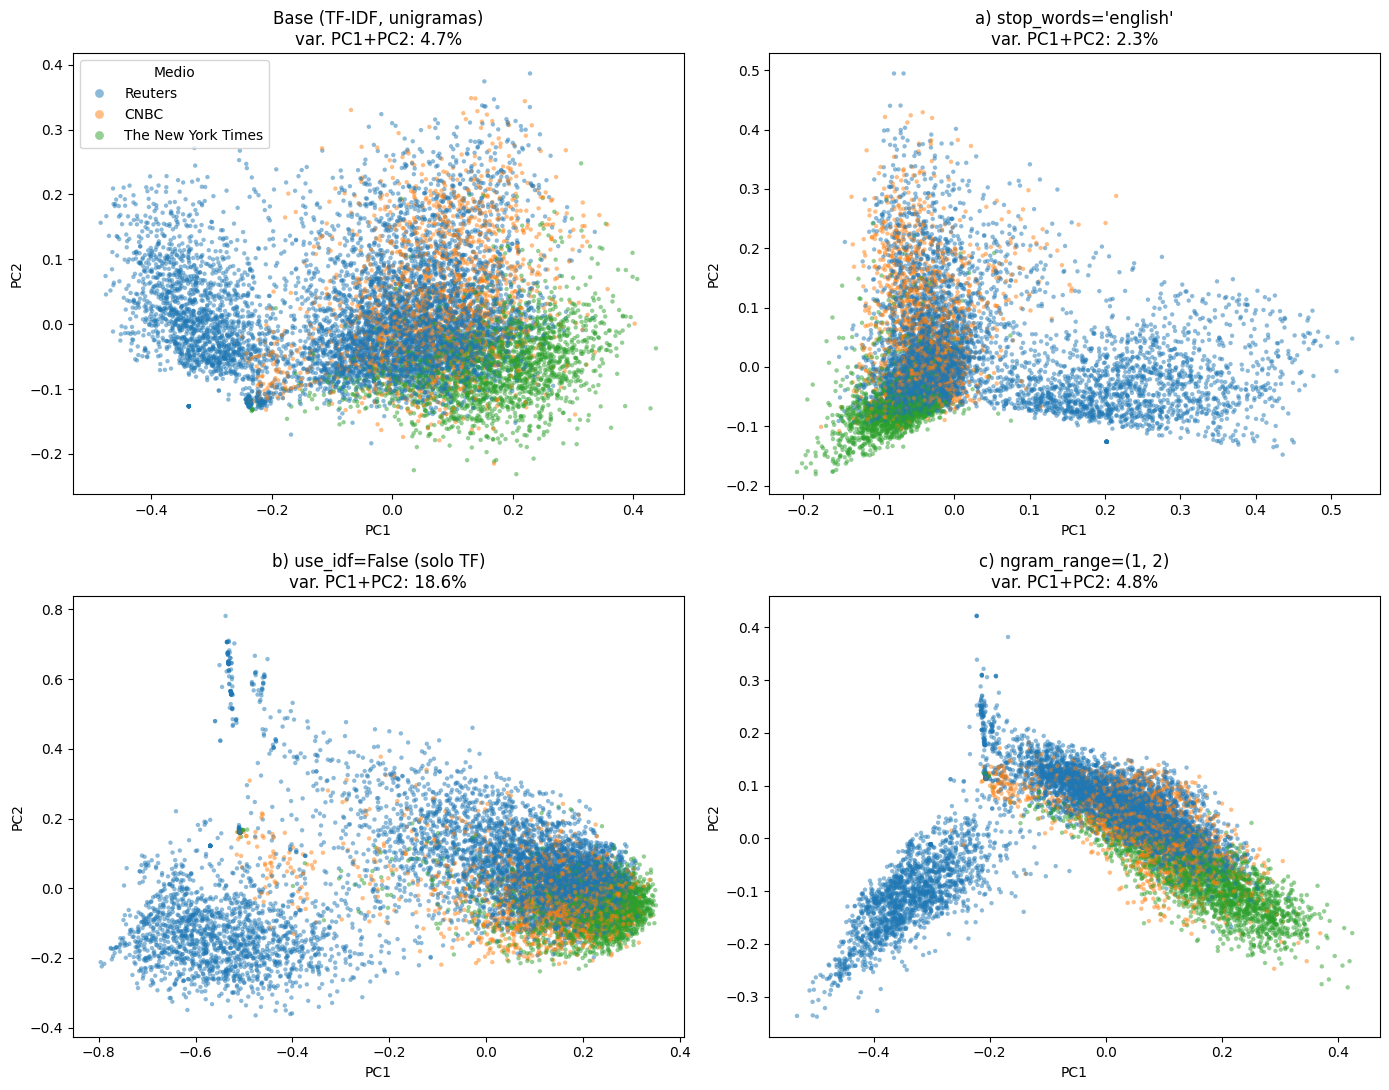

In [59]:
# Comparación de PCA con distintas configuraciones del TfidfVectorizer.
def pca_coords(**tfidf_kwargs):
    """Vectoriza X_train con la config dada, aplica PCA(2) y devuelve coords + varianza explicada."""
    vec = TfidfVectorizer(max_features=MAX_FEATURES, **tfidf_kwargs)
    Xt = vec.fit_transform(X_train)
    p = PCA(n_components=2, random_state=RANDOM_STATE)
    c = p.fit_transform(Xt.toarray())
    return c, p.explained_variance_ratio_[:2].sum()

configs = {
    'Base (TF-IDF, unigramas)':   {},
    "a) stop_words='english'":    {'stop_words': 'english'},
    'b) use_idf=False (solo TF)': {'use_idf': False},
    'c) ngram_range=(1, 2)':      {'ngram_range': (1, 2)},
}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, (name, kw) in zip(axes.ravel(), configs.items()):
    c, ev = pca_coords(**kw)
    sns.scatterplot(
        x=c[:, 0], y=c[:, 1], hue=y_train.values,
        s=10, alpha=0.5, edgecolor='none', #palette='viridis', 
        ax=ax, legend=(ax is axes[0, 0]),
    )
    ax.set_title(f'{name}\nvar. PC1+PC2: {ev:.1%}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    if ax is axes[0, 0]:
        ax.legend(title='Medio', markerscale=2)

plt.tight_layout()
plt.savefig(FIG_DIR / 'pca_configuraciones.png', dpi=150, bbox_inches='tight')
plt.show()


#### Análisis — efecto de las configuraciones del `TfidfVectorizer`

Ninguna configuración logra separar **limpiamente** los tres medios en 2D, pero las diferencias entre ellas son informativas:

- **a) `stop_words='english'`**: al quitar las palabras vacías (*the, of, and*...), que eran muy frecuentes y aportaban varianza **sin discriminar**, la nube deja de ser una **mancha difusa sin forma definida** (como en el base) y se **organiza**: los puntos se alinean según **direcciones/ejes marcados**, dando una estructura más definida. Esto ocurre porque, removidas las palabras de alta frecuencia, las componentes pasan a captar términos con más contenido.
- **b) `use_idf=False` (solo TF normalizado)**: es la que **peor** funciona. Sin la ponderación IDF las palabras frecuentes vuelven a **dominar**: los tres medios se **apelmazan en una misma región** y Reuters (azul) queda **disperso** alrededor, sin formar una zona propia. Se pierde por completo el realce de los términos distintivos.
- **c) `ngram_range=(1, 2)` (unigramas + bigramas)**: incorpora bigramas (frases de dos palabras), que capturan expresiones **características** de cada medio (p. ej. el fraseo formulaico de Reuters). Lejos de dispersar los puntos, **estructura** la nube: se forma una figura en **"V" o de dos lóbulos**, con una **rama izquierda compuesta principalmente por Reuters (azul)** y una **rama derecha donde se solapan los tres medios**. Es la configuración en la que la distintividad de Reuters se hace **más visible**, aunque CNBC (naranja) y NY Times (verde) siguen sin separarse entre sí.

**Conclusión:** la representación influye en la estructura que se observa. **Quitar stop words** organiza la nube (de difusa a ejes marcados) y **agregar bigramas** revela señal —en particular, la rama propia de Reuters—, mientras que **quitar IDF** es lo que más perjudica (apelmaza los medios y dispersa Reuters). Aun así, persiste un **lóbulo de solapamiento** entre los tres medios, por lo que ninguna configuración alcanza una separación nítida de las tres clases en solo 2 componentes.


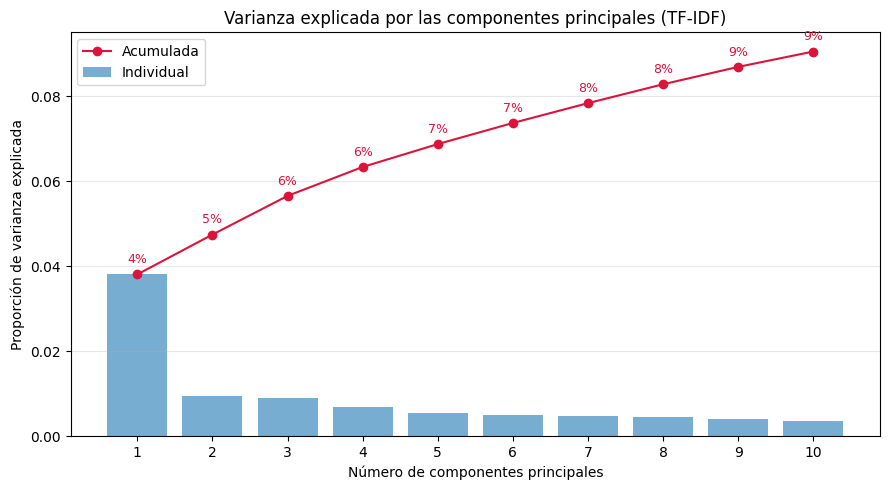

Varianza explicada acumulada con 10 componentes: 9.06%


In [60]:
# Varianza explicada a medida que se agregan componentes (hasta 10), sobre el TF-IDF base.
N_COMPONENTS = 10
pca10 = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
pca10.fit(X_train_tfidf_dense)

evr = pca10.explained_variance_ratio_      # varianza explicada por cada componente
cum = np.cumsum(evr)                        # varianza explicada acumulada

fig, ax = plt.subplots(figsize=(9, 5))
comps = np.arange(1, N_COMPONENTS + 1)
ax.bar(comps, evr, alpha=0.6, label='Individual')
ax.plot(comps, cum, 'o-', color='crimson', label='Acumulada')
for x, y in zip(comps, cum):
    ax.annotate(f'{y:.0%}', (x, y), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9, color='crimson')
ax.set_xlabel('Número de componentes principales')
ax.set_ylabel('Proporción de varianza explicada')
ax.set_title('Varianza explicada por las componentes principales (TF-IDF)')
ax.set_xticks(comps)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'varianza_explicada.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Varianza explicada acumulada con {N_COMPONENTS} componentes: {cum[-1]:.2%}')


#### Análisis — varianza explicada acumulada

El gráfico muestra dos comportamientos:

- **Varianza individual decreciente** (de la componente 1 a la 10): cada componente captura **menos varianza que la anterior**. Esto es *por construcción*, ya que PCA ordena las componentes por valor propio decreciente ($\lambda_1 \ge \lambda_2 \ge \dots$): PC1 es la dirección de máxima varianza, PC2 la siguiente, y así.
- **Varianza acumulada muy baja**: con 2 componentes se explica apenas ≈ **4–5 %** del total, y aun con **10 componentes** solo se alcanza ≈ **9 %**.

**Interpretación:** los vectores TF-IDF son **intrínsecamente de muy alta dimensión** y su varianza está **repartida entre miles de direcciones**, no concentrada en unas pocas. No existe un puñado de componentes que resuma el texto: harían falta cientos o miles para conservar la mayor parte de la información.

Esto **cierra el círculo con la primera pregunta**: si 2 componentes retienen solo ~4–5 % de la varianza, es **esperable** que los medios no se separen en ese plano —estamos viendo una "sombra" muy pobre de los datos. La no-separación visual es, en gran medida, un artefacto de comprimir ~20.000 dimensiones en 2. *(Contrasta con un caso donde PCA funciona muy bien, como el ejemplo de las tortugas del teórico, donde 2 componentes explicaban el 99,4 % porque las variables estaban fuertemente correlacionadas; el texto es el caso opuesto.)*

#### Discusión: ¿estilo editorial, temática o pistas explícitas?

La separación **parcial** que se observa (la zona algo propia de Reuters) puede deberse a una combinación de factores:

- **Pistas explícitas del medio**: nuestra función `clean_text()` elimina el *dateline* inicial (la línea que contenía "(Reuters)", etc.), de modo que las pistas más obvias **ya fueron removidas**. Podría quedar alguna fuga residual (nombres de secciones, términos recurrentes), pero no son la causa principal.
- **Diferencias temáticas**: es el factor más probable. Reuters (*newswire* financiero), CNBC (negocios/finanzas) y NY Times (generalista) cubren agendas distintas y, por lo tanto, vocabularios distintos. Las **dos sub-zonas** de Reuters refuerzan que hay estructura **temática** dentro de un mismo medio.
- **Estilo editorial**: Reuters tiene un estilo formulaico y homogéneo muy reconocible, lo que contribuye a su zona parcialmente diferenciada.

**Cierre:** existe **señal** (temática + estilo) que distingue a los medios, aunque PCA en 2D no la exhiba —por ser no supervisado y por la bajísima varianza retenida. Esa señal **sí** puede ser aprovechada por un clasificador supervisado sobre el espacio TF-IDF completo, como se verá en la Parte 2.


# Parte 2: Entrenamiento y Evaluación de Modelos

## 1. Multinomial Naive Bayes
Entrene el modelo *Multinomial Naive Bayes* para clasificar los artículos según a qué medio de prensa pertenece el texto.
Utilice dicho modelo para clasificar los artículos del conjunto de test, y reporte el valor de *accuracy* y la **matriz de confusión**.
Reporte además el valor de *precision* y *recall* para cada medio.
Explique cómo se relacionan estos valores con la matriz anterior.

¿Qué problemas puede tener el hecho de mirar solamente el valor de *accuracy*?
Considere qué sucedería con esta métrica si el desbalance de datos fuera aún mayor entre medios.

**Sugerencia**: utilice el método `from_predictions` de `ConfusionMatrixDisplay` para realizar la matriz.

### ¿Cómo funciona Multinomial Naive Bayes?

Naive Bayes es un clasificador que decide a qué medio pertenece un artículo usando **probabilidades**. La idea de fondo es bastante intuitiva: a partir de los artículos de entrenamiento, el modelo **aprende qué palabras son típicas de cada medio**. Cuando llega un artículo nuevo, mira las palabras que contiene, calcula qué tan probable es que sea de cada medio, y lo asigna al **más probable**.

Para hacer ese cálculo se apoya en el **teorema de Bayes**, que combina dos cosas:
- qué tan frecuente es cada medio en general (por ejemplo, hay muchos más artículos de Reuters que del resto), y
- qué tan bien las palabras del artículo "encajan" con cada medio.

Quedarse con el medio de mayor probabilidad es lo que se conoce como la **regla de decisión de Bayes** [1].

**¿Por qué "naive" (ingenuo)?** Para simplificar las cuentas, el modelo **supone que cada palabra aporta evidencia por separado**, como si las palabras de un texto fueran independientes entre sí. En realidad no lo son (las palabras de un artículo están relacionadas), pero esta simplificación funciona muy bien en la práctica y vuelve al modelo rápido y sencillo de entrenar [1, 2].

**¿Por qué "multinomial"?** Es la versión pensada para **contar palabras**. Estima la probabilidad de cada palabra en cada medio según cuántas veces aparece en los artículos de ese medio. Para evitar que una palabra nunca vista tenga probabilidad cero (lo que arruinaría el cálculo), suma un pequeño ajuste llamado **suavizado** (el parámetro `alpha`) [2]. Aunque está diseñado para conteos, también se puede usar con pesos **TF-IDF**, que es lo que hacemos en esta tarea.

---
**Referencias**

[1] G. James, D. Witten, T. Hastie y R. Tibshirani, *An Introduction to Statistical Learning*, 2.ª ed., Springer, 2021, cap. 4 (*Classification*, Naive Bayes). https://www.statlearning.com/

[2] scikit-learn, *Naive Bayes* / `MultinomialNB`. https://scikit-learn.org/stable/modules/naive_bayes.html#multinomial-naive-bayes


In [61]:
# Entrenamiento de Multinomial Naive Bayes sobre las features TF-IDF de entrenamiento.
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

# El conjunto de TEST se transforma con el MISMO vectorizador ajustado en train
# (se usa .transform, NO .fit_transform: el vocabulario y los IDF se aprenden solo del train).
X_test_tfidf = tfidf_vectorizer.transform(X_test)
y_pred = nb.predict(X_test_tfidf)

print(f'Modelo entrenado sobre {X_train_tfidf.shape[0]:,} artículos.')
print(f'Predicciones generadas sobre {X_test_tfidf.shape[0]:,} artículos de test.')


Modelo entrenado sobre 10,425 artículos.
Predicciones generadas sobre 4,469 artículos de test.


Accuracy en test: 0.7744

Reporte de clasificación (precision / recall / f1-score por medio):
                    precision    recall  f1-score   support

              CNBC       0.96      0.10      0.18       787
           Reuters       0.76      0.97      0.86      2830
The New York Times       0.80      0.74      0.77       852

          accuracy                           0.77      4469
         macro avg       0.84      0.61      0.60      4469
      weighted avg       0.81      0.77      0.72      4469



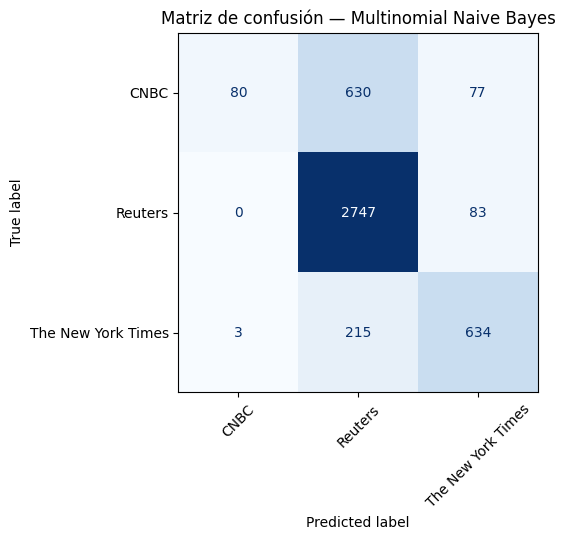

In [62]:
# Evaluación sobre el conjunto de test.
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy en test: {acc:.4f}\n')

# Precision, recall y F1 por medio
print('Reporte de clasificación (precision / recall / f1-score por medio):')
print(classification_report(y_test, y_pred))

# Matriz de confusión (filas = clase real, columnas = clase predicha)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=ax, cmap='Blues', colorbar=False,
    xticks_rotation=45,
)
ax.set_title('Matriz de confusión — Multinomial Naive Bayes')
plt.tight_layout()
plt.savefig(FIG_DIR / 'matriz_confusion_nb_base.png', dpi=150, bbox_inches='tight')
plt.show()


#### Análisis de resultados — Multinomial Naive Bayes

El modelo alcanza un **accuracy de 0,77** en test, pero ese número global esconde comportamientos muy distintos según el medio:

| Medio | Precision | Recall | F1 | Lectura |
|---|---|---|---|---|
| **CNBC** | 0,96 | **0,10** | 0,18 | casi no lo detecta, pero cuando lo predice acierta |
| **Reuters** | 0,76 | **0,97** | 0,86 | lo detecta casi siempre, pero "se lleva" artículos ajenos |
| **NY Times** | 0,80 | 0,74 | 0,77 | desempeño equilibrado |

**Cómo se relacionan precision/recall con la matriz de confusión.** Para cada medio, el **recall** se lee sobre su **fila** (de los artículos que *realmente* son de ese medio, qué fracción se clasificó bien) y la **precision** sobre su **columna** (de los que el modelo *predijo* como ese medio, qué fracción era correcta). Así:
- El **recall de CNBC = 0,10** indica que casi toda la fila de CNBC se desvió hacia otra columna: el modelo confunde la gran mayoría de los artículos de CNBC con **Reuters**.
- El **recall de Reuters = 0,97** junto con su **precision = 0,76** muestra que el modelo **sobre-predice** Reuters: acapara casi todos sus artículos pero también recibe los CNBC mal clasificados, lo que ensucia su precisión.

**Por qué ocurre.** Hay dos causas que se combinan:
1. **Desbalance de clases**: Reuters representa ~63 % del conjunto, así que el modelo tiene un fuerte sesgo a predecir la clase mayoritaria "ante la duda".
2. **Similitud temática**: CNBC y Reuters son ambos medios de **negocios/finanzas** y comparten vocabulario, por lo que son difíciles de distinguir. Esto es coherente con lo observado en el PCA, donde CNBC no formaba un grupo propio y se solapaba con Reuters.

**El problema de mirar solo el accuracy.** Un clasificador trivial que predijera *siempre* "Reuters" ya obtendría un accuracy de **0,63** (2830/4469), apenas por debajo del 0,77 del modelo. Es decir, el accuracy global **premia acertar la clase mayoritaria** y **oculta** que CNBC prácticamente no se detecta (recall 0,10). La señal de alerta aparece al comparar el **macro avg** (recall 0,61, F1 0,60) —que pondera los tres medios por igual— con el accuracy: la diferencia revela que el buen número global se debe sobre todo a Reuters.

**Qué pasaría con un desbalance aún mayor.** Si un medio concentrara, por ejemplo, el 95 % de los artículos, el clasificador trivial "todo a la clase mayoritaria" alcanzaría un **95 % de accuracy** sin aprender nada útil, ignorando por completo a las clases minoritarias. Por eso, en problemas desbalanceados, el accuracy por sí solo es engañoso y conviene apoyarse en **precision y recall por clase**, el **F1 macro** y la **matriz de confusión**.


#### Investigación: ¿CNBC republica contenido de Reuters?

La confusión sistemática de CNBC con Reuters nos llevó a revisar los **datos** (no solo el modelo). La hipótesis: CNBC sindica/republica cables de la agencia Reuters, de modo que muchos artículos etiquetados como "CNBC" son, en su contenido, material de Reuters. Lo verificamos a continuación y, además, probamos si la confusión se debía simplemente a que la palabra "reuters" funcionaba como pista.


In [63]:
# 1) Indicios de contenido sindicado: ¿cuántos artículos mencionan "reuters" en el cuerpo?
raw = {pub: df_top_3.loc[df_top_3['publication'] == pub, 'article'].fillna('').str.lower()
       for pub in ['CNBC', 'Reuters', 'The New York Times']}

print('% de artículos que mencionan "reuters" en el texto:')
for pub, art in raw.items():
    print(f'  {pub:<20}: {art.str.contains("reuters").mean():6.1%}')

# 2) Textos 100% idénticos compartidos entre medios distintos (republicación literal)
dups = df_top_3[df_top_3.duplicated(subset='article', keep=False)]
cross = (dups.groupby('article')['publication'].nunique() > 1).sum()
print(f'\nArtículos con texto idéntico en >1 medio (republicación literal cruzada): {cross}')

# 3) Títulos idénticos compartidos entre CNBC y Reuters
common_titles = (set(df_top_3.loc[df_top_3['publication'] == 'CNBC', 'title'].dropna()) &
                 set(df_top_3.loc[df_top_3['publication'] == 'Reuters', 'title'].dropna()))
print(f'\nTítulos idénticos en CNBC y Reuters: {len(common_titles)}')
for t in list(common_titles)[:5]:
    print('  -', str(t)[:80])


% de artículos que mencionan "reuters" en el texto:
  CNBC                :  31.3%
  Reuters             :  92.5%
  The New York Times  :   1.6%

Artículos con texto idéntico en >1 medio (republicación literal cruzada): 0

Títulos idénticos en CNBC y Reuters: 3
  - Huawei says MWC events still on, watching coronavirus developments
  - Twitter testing disappearing 'fleets' in Brazil
  - METALS-Copper rises for fourth day as Trump hails trade progress


In [64]:
# Experimento: ¿la confusión se debe al literal "reuters"? Lo quitamos del texto y reentrenamos.
def entrenar_y_evaluar(textos, etiqueta):
    Xtr, Xte, ytr, yte = train_test_split(
        textos, df_top_3['publication'],
        test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df_top_3['publication'],
    )
    vec = TfidfVectorizer(max_features=MAX_FEATURES)
    modelo = MultinomialNB().fit(vec.fit_transform(Xtr), ytr)
    y_p = modelo.predict(vec.transform(Xte))
    print(f'=== {etiqueta} ===  accuracy = {accuracy_score(yte, y_p):.4f}')
    print(classification_report(yte, y_p, digits=2))

# Quitamos el token "reuters" del texto ya limpio
texto_sin_reuters = (
    df_top_3['CleanText']
    .str.replace(r'\breuters\b', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

entrenar_y_evaluar(df_top_3['CleanText'], 'BASELINE (con "reuters")')
entrenar_y_evaluar(texto_sin_reuters, 'SIN la palabra "reuters"')


=== BASELINE (con "reuters") ===  accuracy = 0.7744
                    precision    recall  f1-score   support

              CNBC       0.96      0.10      0.18       787
           Reuters       0.76      0.97      0.86      2830
The New York Times       0.80      0.74      0.77       852

          accuracy                           0.77      4469
         macro avg       0.84      0.61      0.60      4469
      weighted avg       0.81      0.77      0.72      4469

=== SIN la palabra "reuters" ===  accuracy = 0.7736
                    precision    recall  f1-score   support

              CNBC       0.96      0.10      0.18       787
           Reuters       0.76      0.97      0.85      2830
The New York Times       0.80      0.74      0.77       852

          accuracy                           0.77      4469
         macro avg       0.84      0.60      0.60      4469
      weighted avg       0.81      0.77      0.72      4469



#### Conclusiones de la investigación

Los resultados confirman la hipótesis, pero con un matiz importante:

- **No hay republicación literal masiva**: prácticamente no existen artículos con texto 100 % idéntico entre medios distintos.
- **Sí hay fuerte rastro de sindicación**: el **31,3 %** de los artículos de CNBC mencionan "reuters" en el cuerpo, frente a solo **1,6 %** en NY Times. Aparecen además títulos idénticos en CNBC y Reuters, alguno con el formato típico de los cables de la agencia (p. ej. *"METALS-Copper rises for fourth day..."*). Es decir, **parte del contenido de CNBC proviene de cables de Reuters**.
- **Pero la confusión no se debe a una sola palabra delatora**: al quitar el token "reuters" del texto, el desempeño **no cambia** (accuracy 0,7744 → 0,7736; el recall de CNBC sigue en 0,10).

**Interpretación.** La confusión CNBC ↔ Reuters no proviene de una pista superficial (la palabra "reuters"), sino del **solapamiento profundo de vocabulario y contenido**: como buena parte del material de CNBC *es*, en los hechos, contenido de Reuters, esos artículos **se leen como Reuters en su totalidad**. Por lo tanto, el bajo recall de CNBC refleja en parte una **ambigüedad genuina en las etiquetas** del dataset —no únicamente una limitación del clasificador—. Esto es coherente con el PCA, donde CNBC no formaba un grupo propio y se solapaba con Reuters.


## 2. Validación cruzada y búsqueda de hiperparámetros
Explique cómo funciona la técnica de **validación cruzada** (*cross-validation*).
Implemente una búsqueda de hiperparámetros usando `GridSearchCV`.
Genere una visualización que permita comparar las métricas (por ejemplo, *accuracy*) de los distintos modelos entrenados, viendo el valor promedio y la variabilidad de las mismas en todos los *splits* (por ejemplo, en un gráfico de violín).

### ¿Qué es la validación cruzada (*cross-validation*)?

Si evaluáramos el modelo con **una sola** división train/validación, el resultado dependería mucho de **qué artículos cayeron por azar** en cada parte: con suerte da bien, con mala suerte da mal. La validación cruzada resuelve esto promediando varias divisiones.

La idea, en simple:

1. Se divide el conjunto de entrenamiento en **k partes iguales** (llamadas *folds*; acá usamos **k = 5**).
2. Se entrena el modelo con **k − 1 partes** y se evalúa con la parte que quedó afuera.
3. Se repite **k veces**, de modo que **cada parte sirve una vez como validación** y el resto para entrenar.
4. Se obtienen k mediciones (una por fold) y se reporta su **promedio**.

Esto da una estimación **más confiable** del desempeño (no depende de una única división afortunada), y además la **variabilidad** entre los folds nos dice qué tan **estable** es el modelo: si los 5 valores son parecidos, el modelo es consistente; si varían mucho, es sensible a los datos con que se entrena [1, 2].

Usamos la validación cruzada dentro de **`GridSearchCV`**, que prueba muchas **combinaciones de hiperparámetros**, estima la calidad de cada una con CV y se queda con la mejor —todo **sin tocar el conjunto de test**, que se reserva para la evaluación final.

---
**Referencias**

[1] G. James, D. Witten, T. Hastie y R. Tibshirani, *An Introduction to Statistical Learning*, 2.ª ed., Springer, 2021, cap. 5 (*Resampling Methods*, validación cruzada). https://www.statlearning.com/

[2] scikit-learn, *Cross-validation: evaluating estimator performance*. https://scikit-learn.org/stable/modules/cross_validation.html


In [65]:
# Búsqueda de hiperparámetros con validación cruzada (5 folds).
from sklearn.pipeline import Pipeline

# Pipeline: vectorización + modelo en un solo objeto, para que el TF-IDF se ajuste
# usando solo los datos de entrenamiento de cada fold (evita filtrar información).
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=MAX_FEATURES)),
    ('nb', MultinomialNB()),
])

# Grilla de hiperparámetros a probar
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],   # unigramas vs. unigramas + bigramas
    'nb__alpha': [0.1, 0.5, 1.0],             # suavizado de Naive Bayes
}

grid_search = GridSearchCV(
    pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print('Mejor combinación de hiperparámetros:', grid_search.best_params_)
print(f'Accuracy promedio (validación cruzada): {grid_search.best_score_:.4f}')


KeyboardInterrupt: 

In [66]:
# Comparación de los modelos: distribución del accuracy en los 5 folds (promedio y variabilidad).
res = pd.DataFrame(grid_search.cv_results_)
split_cols = [c for c in res.columns if c.startswith('split') and c.endswith('_test_score')]

# Etiqueta legible por combinación de hiperparámetros
res['modelo'] = res['params'].apply(
    lambda p: f"alpha={p['nb__alpha']}, ngram={p['tfidf__ngram_range']}"
)

# Formato largo: una fila por (modelo, fold)
largo = res.melt(id_vars='modelo', value_vars=split_cols, value_name='accuracy')

# Orden de mejor a peor según el accuracy promedio
orden = res.sort_values('mean_test_score', ascending=False)['modelo']

plt.figure(figsize=(10, 6))
sns.violinplot(data=largo, x='accuracy', y='modelo', order=orden,
               palette='viridis', inner='point', cut=0)
plt.xlabel('Accuracy (en cada uno de los 5 folds)')
plt.ylabel('Modelo (hiperparámetros)')
plt.title('Comparación de modelos por validación cruzada (5 folds)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'cv_violin_modelos.png', dpi=150, bbox_inches='tight')
plt.show()


AttributeError: 'GridSearchCV' object has no attribute 'cv_results_'

#### Análisis — búsqueda de hiperparámetros

La validación cruzada (5 folds) sobre las combinaciones probadas arroja:

- **Mejor modelo**: `alpha = 0.5` con `ngram_range = (1, 2)` (unigramas + bigramas), con un accuracy promedio de **≈ 0,82**.
- **Los bigramas ayudan claramente**: todas las configuraciones con `(1, 2)` superan a sus equivalentes con solo unigramas, porque capturan frases características de cada medio.
- **El suavizado importa**: un `alpha` más bajo (0,5 o 0,1) funciona mejor que el valor por defecto (1,0).
- El modelo *por defecto* (`alpha = 1.0`, solo unigramas) es el **peor** (≈ 0,77), coincidiendo con el resultado del punto anterior.

En el gráfico de violín, cada violín muestra la **distribución del accuracy en los 5 folds** de un modelo: su posición indica el **promedio** y su ancho la **variabilidad**. Las variaciones entre folds son **pequeñas** (desvíos del orden de 0,003–0,006), lo que indica que los resultados son **estables** y no dependen de una división particular de los datos.


#### ¿Por qué *k* = 5? (justificación empírica)

Para no elegir *k* de forma arbitraria, repetimos la validación cruzada del mejor modelo variando el número de folds y comparamos tres cosas: la **estimación** de accuracy, su **variabilidad** entre folds y el **tiempo de cómputo**. La idea es ver a partir de qué *k* la estimación deja de mejorar y solo crece el costo.


In [ ]:
# Comparación de la validación cruzada para distintos valores de k (sobre el mejor modelo).
pipe_mejor = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=(1, 2))),
    ('nb', MultinomialNB(alpha=0.5)),
])

ks = [2, 3, 5, 10]
filas = []
for k in ks:
    t0 = time()
    sc = cross_val_score(pipe_mejor, X_train, y_train, cv=k, scoring='accuracy', n_jobs=-1)
    filas.append({'k': k, 'accuracy_media': sc.mean(), 'std': sc.std(), 'tiempo_s': time() - t0})

tabla_k = pd.DataFrame(filas)
print(tabla_k.to_string(index=False))

# Gráfico: estimación (con barras de variabilidad) y tiempo, en funcion de k
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.errorbar(tabla_k['k'], tabla_k['accuracy_media'], yerr=tabla_k['std'],
             marker='o', capsize=4, color='steelblue', label='Accuracy media ± std')
ax1.set_xlabel('k (número de folds)')
ax1.set_ylabel('Accuracy (validación cruzada)', color='steelblue')
ax1.set_xticks(ks)
ax1.axvline(5, color='gray', linestyle='--', alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(tabla_k['k'], tabla_k['tiempo_s'], marker='s', color='crimson', label='Tiempo')
ax2.set_ylabel('Tiempo de cómputo (s)', color='crimson')

ax1.set_title('Validación cruzada: estimación y costo según k')
fig.tight_layout()
plt.savefig(FIG_DIR / 'cv_k_estimacion_costo.png', dpi=150, bbox_inches='tight')
plt.show()


El experimento muestra el clásico compromiso al elegir *k*:

| k | Accuracy media | Std (variabilidad) | Tiempo |
|---|---|---|---|
| 2 | 0,8156 | 0,0021 | ~9 s |
| 3 | 0,8179 | 0,0036 | ~10 s |
| **5** | **0,8189** | 0,0057 | ~16 s |
| 10 | 0,8199 | 0,0093 | ~49 s |

- **La estimación casi no cambia**: de k = 2 a k = 10 la accuracy media solo pasa de 0,816 a 0,820 (menos de medio punto). Crece levemente con *k* porque cada modelo entrena con más datos, pero **en k = 5 ya está prácticamente en su valor final** (a 0,001 de k = 10).
- **La variabilidad aumenta con *k***: con más folds, cada conjunto de validación es más chico y la medición por fold se vuelve más ruidosa (la std sube de 0,002 a 0,009).
- **El tiempo crece rápido**: k = 10 tarda ~3× más que k = 5 para obtener esencialmente la misma estimación. *(Los tiempos dependen de la máquina; las accuracies son deterministas.)*

**Conclusión:** **k = 5 es el mejor equilibrio**: entrega prácticamente la misma estimación que k = 10 a un tercio del costo, con una variabilidad moderada. Además, con k = 5 cada modelo entrena con el 80 % de los datos, la misma proporción que nuestro split train/test. Por eso se adopta k = 5 en la búsqueda de hiperparámetros.


## 3. Entrenamiento final con el mejor modelo
Elija el mejor modelo (mejores parámetros) y vuelva a entrenar sobre todo el conjunto de entrenamiento disponible (sin quitar datos para validación).
Reporte el valor final de las métricas y la matriz de confusión.
Discuta las limitaciones de utilizar un modelo basado en *bag of words* o TF-IDF para el análisis de texto.

In [ ]:
# Modelo final: la mejor configuración hallada por GridSearchCV.
# Con refit=True (por defecto), GridSearchCV ya reentrenó esa configuración sobre
# TODO el conjunto de entrenamiento (sin reservar datos para validación).
modelo_final = grid_search.best_estimator_
print('Mejor configuración:', grid_search.best_params_)

# Predicciones sobre el conjunto de test (el pipeline aplica el TF-IDF y luego NB)
y_pred_final = modelo_final.predict(X_test)
print(f'Predicciones generadas sobre {len(X_test):,} artículos de test.')


Mejor configuración: {'nb__alpha': 0.5, 'tfidf__ngram_range': (1, 2)}
Predicciones generadas sobre 4,469 artículos de test.


In [ ]:
# Métricas finales sobre el conjunto de test.
acc = accuracy_score(y_test, y_pred_final)
print(f'Accuracy final en test: {acc:.4f}\n')
print('Reporte de clasificación (precision / recall / f1 por medio):')
print(classification_report(y_test, y_pred_final))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final, ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45,
)
ax.set_title('Matriz de confusión — modelo final (TF-IDF bigramas + Naive Bayes)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'matriz_confusion_modelo_final.png', dpi=150, bbox_inches='tight')
plt.show()


#### Análisis — modelo final vs. modelo base

Comparado con el Naive Bayes inicial (unigramas, `alpha=1.0`), el modelo afinado mejora de forma clara, sobre todo en **equilibrio entre clases**:

| Métrica | Modelo base (2.1) | **Modelo final** |
|---|---|---|
| Accuracy | 0,77 | **0,81** |
| **F1 macro** | 0,60 | **0,73** |
| Recall CNBC | 0,10 | **0,45** |
| Recall NY Times | 0,74 | **0,88** |
| Precision Reuters | 0,76 | **0,87** |

- La mejora más importante **no es el accuracy** (sube poco, de 0,77 a 0,81) sino el **F1 macro** (0,60 → 0,73), que pondera los tres medios por igual: el modelo dejó de **limitarse a predecir Reuters** y empezó a **distinguir** las clases.
- **CNBC** pasa de un recall de 0,10 a **0,45**: ahora detecta casi la mitad de sus artículos (antes, casi ninguno). El costo es una caída de su precision (de 0,96 a 0,72), es decir, el clásico **compromiso precision/recall**: al "animarse" a predecir CNBC más seguido, acierta muchos más reales pero también suma algunos falsos positivos.
- **Reuters** mejora su precision (0,76 → 0,87): al no acaparar todas las predicciones, comete menos errores al asignar esa etiqueta.
- En la **matriz de confusión**, la confusión CNBC → Reuters disminuye pero **no desaparece**, coherente con la sindicación de contenido detectada antes: parte de los artículos de CNBC realmente *son* material de Reuters.

La clave de la mejora son los **bigramas**, que capturan frases distintivas de cada medio, y un **`alpha` menor**, que da más peso a la evidencia de los datos.


#### Limitaciones de un modelo basado en Bag of Words / TF-IDF

Aunque el modelo funciona razonablemente, las representaciones BOW y TF-IDF tienen limitaciones de fondo:

- **Ignoran el orden y el contexto.** Al ser una "bolsa de palabras", *"no es un buen día"* y *"es un buen día, no"* se representan casi igual. No capturan **negación**, ironía ni matices que dependen del orden (los n-gramas ayudan algo, pero de forma limitada).
- **No entienden el significado (semántica).** Cada palabra es una dimensión independiente: *"auto"* y *"automóvil"* se tratan como cosas totalmente distintas, aunque signifiquen lo mismo. El modelo no reconoce **sinónimos** ni relaciones entre conceptos.
- **Dependen del vocabulario exacto.** Una palabra que no apareció en el entrenamiento se **ignora** en el test. El modelo se apoya en coincidencias superficiales de palabras, no en el sentido del texto.
- **Alta dimensionalidad y dispersión.** El vocabulario genera miles de atributos casi siempre en cero (lo vimos en el PCA: 2 componentes explicaban muy poca varianza), lo que dificulta el análisis y puede favorecer el sobreajuste.
- **Confunden estilo/tema con autoría real.** Como solo miran qué palabras aparecen, no pueden separar contenidos que comparten vocabulario (p. ej. CNBC y Reuters), aun cuando provengan de fuentes distintas.

Estas limitaciones se atacan con representaciones más ricas, como los **word embeddings** (Word2Vec, GloVe) o los modelos basados en *transformers*, que generan vectores densos capaces de capturar **significado y contexto** —algo que se retoma en la sección de técnicas alternativas de extracción de *features*— [1, 2].

---
**Referencias**

[1] D. Jurafsky y J. H. Martin, *Speech and Language Processing* (3.ª ed., borrador), capítulos de semántica vectorial y *embeddings*. https://web.stanford.edu/~jurafsky/slp3/

[2] scikit-learn, *Text feature extraction* (limitaciones del modelo Bag of Words). https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction


## 4. Modelo alternativo
Evalúe al menos un modelo más (dentro de scikit-learn) aparte de *Multinomial Naive Bayes* para clasificar el texto utilizando las mismas *features* de texto.
Explique brevemente cómo funciona y compare los resultados con el anterior.

### ¿Cómo funciona una SVM (máquina de vectores de soporte)?

Una **SVM** (*Support Vector Machine*) busca la **frontera que mejor separa las clases**, eligiéndola de modo que quede lo más "lejos" posible de los puntos de cada clase. Más en concreto, traza un **hiperplano** que **maximiza el margen**: la distancia entre la frontera y los puntos más cercanos de cada clase, llamados **vectores de soporte**. Cuanto más ancho es ese margen, mejor tiende a generalizar el modelo. Cuando los datos no son perfectamente separables, permite cierto error controlado (*soft margin*); y si la separación no es lineal, puede transformar los datos a un espacio de mayor dimensión (*kernel*) [1, 2].

Para texto usamos **`LinearSVC`** (SVM con frontera lineal), que es muy eficaz en espacios de **alta dimensión y dispersos** como los de TF-IDF. El problema multiclase (3 medios) se resuelve internamente con la estrategia *uno-contra-el-resto*. A diferencia de Naive Bayes, **no asume que las palabras sean independientes**: pondera todas las *features* en conjunto para encontrar la mejor frontera.


In [ ]:
# Modelo alternativo: SVM lineal con las MISMAS features TF-IDF (bigramas) que el modelo final.
from sklearn.svm import LinearSVC

svm = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=(1, 2))),
    ('svc', LinearSVC(random_state=RANDOM_STATE)),
])
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print(f'Accuracy (SVM lineal) en test: {accuracy_score(y_test, y_pred_svm):.4f}\n')
print('Reporte de clasificación (precision / recall / f1 por medio):')
print(classification_report(y_test, y_pred_svm))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm, ax=ax, cmap='Greens', colorbar=False, xticks_rotation=45,
)
ax.set_title('Matriz de confusión — SVM lineal (LinearSVC)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'matriz_confusion_svm.png', dpi=150, bbox_inches='tight')
plt.show()


#### Comparación: SVM lineal vs. Naive Bayes

| Métrica | Naive Bayes (final) | **SVM lineal** |
|---|---|---|
| Accuracy | 0,81 | **0,90** |
| F1 macro | 0,73 | **0,86** |
| Precision / Recall CNBC | 0,72 / 0,45 | **0,87 / 0,63** |
| F1 Reuters | 0,88 | **0,93** |
| F1 NY Times | 0,77 | **0,93** |

La **SVM lineal supera claramente a Naive Bayes** en todas las métricas: el accuracy sube de 0,81 a **0,90** y el F1 macro de 0,73 a **0,86**, con mejoras parejas en los tres medios. La mejora más fuerte sigue siendo en **CNBC** (recall 0,45 → 0,63), el medio más difícil.

**¿Por qué anda mejor?** Naive Bayes asume que las palabras son **independientes** dada la clase, lo cual es falso para texto real. La SVM no hace esa suposición: busca directamente la **frontera de máximo margen** considerando todas las palabras en conjunto, algo que funciona muy bien en los espacios de alta dimensión y dispersos del TF-IDF. Por eso, el SVM lineal sobre TF-IDF es un *baseline* clásico y fuerte para clasificación de texto.

**Lo que no cambia:** en la matriz de confusión, la confusión **CNBC → Reuters** disminuye pero **no desaparece** (sigue siendo el error más frecuente). Esto refuerza que parte de esa confusión es una **limitación de los datos** (contenido de Reuters sindicado por CNBC), no del clasificador: ningún modelo puede distinguir como "CNBC" un texto que, en los hechos, es de Reuters.

---
**Referencias**

[1] M. Bourel, *Statistical Learning / Aprendizaje supervisado* (Support Vector Machines), Introducción a la Ciencia de Datos, IMERL – FING, UdelaR.

[2] scikit-learn, *Support Vector Machines* / `LinearSVC`. https://scikit-learn.org/stable/modules/svm.html


## 5. Cambio de medio de prensa
Evalúe el problema cambiando al menos un medio de prensa.
En particular, observe el (des)balance de datos y los problemas que pueda generar, así como cualquier indicio que pueda ver en el mapeo previo con PCA.
Puede ser útil comentar acerca de técnicas como sobre-muestreo y submuestreo; no es necesario implementarlas.

In [ ]:
# Nueva combinación de medios: los 3 más PAREJOS del top 10 (cambiamos los tres respecto al original).
from sklearn.svm import LinearSVC

# Recargamos el dataset completo en una variable propia (evita depender de `df`,
# que pudo haberse sobrescrito en celdas anteriores).
df_full = load_dataset_hf()

trio_balanceado = ['Refinery 29', 'Vice', 'Mashable']
df_bal = df_full[df_full['publication'].isin(trio_balanceado)].copy()
df_bal['CleanText'] = clean_text(df_bal, 'article')

conteos = df_bal['publication'].value_counts()
print('Balance de clases (nuevo conjunto):')
print(conteos.to_string())
print(f'Total: {len(df_bal):,}  |  ratio máx/mín = {conteos.max() / conteos.min():.2f}')

# Partición estratificada (mismos parámetros que antes)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    df_bal['CleanText'], df_bal['publication'],
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df_bal['publication'],
)

# Reentrenamos los dos modelos con la misma representación (TF-IDF bigramas)
for nombre, clf in [('Naive Bayes', MultinomialNB(alpha=0.5)),
                    ('SVM lineal', LinearSVC(random_state=RANDOM_STATE))]:
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=(1, 2))),
        ('clf', clf),
    ])
    pipe.fit(Xb_train, yb_train)
    yb_pred = pipe.predict(Xb_test)
    print(f'\n=== {nombre} ===  accuracy = {accuracy_score(yb_test, yb_pred):.4f}')
    print(classification_report(yb_test, yb_pred))


Balance de clases (nuevo conjunto):
publication
Refinery 29    1236
Vice           1154
Mashable       1045
Total: 3,435  |  ratio máx/mín = 1.18

=== Naive Bayes ===  accuracy = 0.7847
              precision    recall  f1-score   support

    Mashable       0.98      0.57      0.72       314
 Refinery 29       0.81      0.85      0.83       371
        Vice       0.69      0.91      0.78       346

    accuracy                           0.78      1031
   macro avg       0.83      0.78      0.78      1031
weighted avg       0.82      0.78      0.78      1031


=== SVM lineal ===  accuracy = 0.8293
              precision    recall  f1-score   support

    Mashable       0.90      0.76      0.82       314
 Refinery 29       0.82      0.85      0.84       371
        Vice       0.79      0.87      0.82       346

    accuracy                           0.83      1031
   macro avg       0.84      0.83      0.83      1031
weighted avg       0.83      0.83      0.83      1031



In [ ]:
# PCA (2 componentes) sobre el nuevo trio, para ver si estos medios se separan.
vec_bal = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=(1, 2))
Xb_tfidf = vec_bal.fit_transform(Xb_train)
coords_bal = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Xb_tfidf.toarray())

plt.figure(figsize=(8, 6))
sns.scatterplot(x=coords_bal[:, 0], y=coords_bal[:, 1], hue=yb_train.values,
                s=14, alpha=0.5, palette='viridis', edgecolor='none')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (2 componentes) — medios parejos (Refinery 29 / Vice / Mashable)')
plt.legend(title='Medio', markerscale=2)
plt.tight_layout()
plt.savefig(FIG_DIR / 'pca_medios_balanceados.png', dpi=150, bbox_inches='tight')
plt.show()


#### Análisis — cambio de medios y efecto del balance

Elegimos los **3 medios más parejos del top 10**: **Refinery 29 (1.236)**, **Vice (1.154)** y **Mashable (1.045)**, con un ratio máx/mín de solo **1,18** (frente al conjunto original, donde Reuters concentraba ~63 %).

**Resultados (test):**

| Métrica | Naive Bayes | SVM lineal |
|---|---|---|
| Accuracy | 0,78 | 0,83 |
| F1 macro | 0,78 | 0,83 |

**El efecto del balance se ve clarísimo al comparar `accuracy` con `F1 macro`:**

- En el conjunto **original (desbalanceado)**, el accuracy era **mayor** que el F1 macro (NB: 0,81 vs 0,73), porque acertar la clase mayoritaria (Reuters) "inflaba" el accuracy.
- En este conjunto **balanceado**, **accuracy ≈ F1 macro** (NB: 0,78 ≈ 0,78; SVM: 0,83 ≈ 0,83): sin una clase dominante, el accuracy global ya refleja de forma honesta el desempeño en cada medio.

Además, **ninguna clase queda "abandonada"**: el peor recall ahora es el de Mashable (0,57 con NB, 0,76 con SVM), muy lejos del recall de 0,10 que sufría CNBC en el conjunto desbalanceado. El balance hace que el modelo reparta su atención de forma más equitativa entre las tres clases.

> Nota: el accuracy de este conjunto (0,83 con SVM) es **menor** que el del original (0,90), pero eso **no significa que el modelo sea peor**. En el original, Reuters era una clase enorme y de estilo muy distintivo (cables de agencia), fácil de acertar, lo que elevaba el número global. Aquí no hay esa "clase fácil", y los tres medios de estilo digital/cultural comparten más vocabulario, por lo que el problema es genuinamente más parejo y algo más difícil.

**Indicios en el PCA.** El mapa PCA de este trio (celda anterior) muestra una **tendencia de separación** que en CNBC/Reuters no aparecía. Aunque hay un núcleo central de solapamiento, cada medio ocupa una **región preferente**, formando una especie de gradiente diagonal: **Mashable** se concentra hacia arriba-izquierda, **Refinery 29** hacia abajo-derecha, y **Vice** queda en el medio, superpuesto con los otros dos. No son tres grupos completamente nítidos, pero la estructura es más clara que la del trio original. Esto es coherente con que (a) son medios temáticamente más distintos (tecnología, moda/lifestyle, cultura joven) y (b) **no hay contenido sindicado cruzado** como ocurría con CNBC/Reuters. De todos modos, como dos componentes siguen explicando poca varianza, la separación total no se ve en el plano: esa señal la terminan aprovechando los clasificadores (que alcanzan 0,78–0,83 de accuracy).

**Sobre el (des)balance: sobre-muestreo y submuestreo.** Cuando un conjunto está muy desbalanceado (como el original con Reuters), existen técnicas para mitigarlo, que aquí **no fueron necesarias** por tratarse de clases parejas:

- **Submuestreo (*undersampling*)**: descartar ejemplos de la clase mayoritaria hasta equilibrar. Simple, pero **desperdicia datos** (y por lo tanto información).
- **Sobre-muestreo (*oversampling*)**: replicar (o sintetizar, p. ej. con SMOTE) ejemplos de las clases minoritarias. Aprovecha todos los datos, pero **puede sobreajustar** a los ejemplos repetidos.
- **Pesos por clase** (`class_weight='balanced'`): penalizar más los errores en las clases minoritarias durante el entrenamiento, sin alterar los datos.

Estas técnicas habrían sido útiles en el conjunto original para mejorar la detección de CNBC, a costa de algún compromiso en la clase mayoritaria.


## 6. Técnica alternativa de extracción de features
Busque información sobre al menos una técnica alternativa de extraer *features* de texto.
Explique brevemente cómo funciona y qué tipo de diferencias esperaría en los resultados.
No se espera que implemente nada en esta parte.

### Técnica alternativa: representaciones contextuales con *Transformers*

BOW y TF-IDF representan cada texto por las **palabras que contiene**, en vectores enormes y dispersos que ignoran el orden y el significado. Una familia de técnicas más moderna genera **vectores densos** (de pocos cientos de dimensiones) que **capturan el sentido** del texto.

**Primer paso — *word embeddings* (Word2Vec, GloVe).** Aprenden, a partir de grandes cantidades de texto, un vector por palabra de modo que **palabras con significado parecido queden cerca** en el espacio (p. ej. *"auto"* y *"automóvil"*). Su limitación: son **estáticos**, asignan el mismo vector a una palabra sin importar el contexto (*"banco"* de plaza vs. *"banco"* financiero reciben el mismo vector) [1].

**Transformers (BERT y similares).** Generan ***embeddings* contextuales**: el vector de cada palabra **depende de la oración en que aparece**, gracias al mecanismo de **atención** (*self-attention*), que hace que el modelo "mire" todas las palabras del texto y pondere cuáles son relevantes entre sí [2, 3]. Así, la misma palabra obtiene representaciones distintas según el contexto, y el modelo capta orden, negaciones y matices de significado.

**Cómo se usarían como *features*.** Se toma un modelo **pre-entrenado** (BERT, RoBERTa, o modelos tipo *sentence-transformers*) y se transforma cada artículo en un **único vector denso** que lo resume; ese vector alimenta luego a un clasificador. Alternativamente, se puede **ajustar** (*fine-tuning*) el propio transformer al problema.

**Diferencias esperadas en los resultados.**

- **A favor:** al capturar **contexto y significado** (y no solo palabras sueltas), suelen lograr **mejor desempeño**, sobre todo cuando la distinción entre clases depende de matices semánticos y no solo del vocabulario. Además, sus vectores son **densos y de baja dimensión**, sin el problema de dispersión del TF-IDF.
- **En contra:** son **mucho más costosos** (requieren GPU y modelos grandes pre-entrenados), **menos interpretables** que TF-IDF, y pueden ser **excesivos** para una tarea relativamente simple.
- **En este problema en particular:** TF-IDF + SVM ya alcanza ~0,90 de accuracy, así que la mejora de un transformer probablemente sería **moderada**. Y un punto importante: la confusión **CNBC ↔ Reuters** se debe a **contenido sindicado** (artículos de CNBC que en realidad son de Reuters); eso es una **ambigüedad de las etiquetas**, no del tipo de *features*, así que **ninguna representación —por más potente que sea— podría resolverla**.

---
**Referencias**

[1] T. Mikolov et al., *Efficient Estimation of Word Representations in Vector Space* (Word2Vec), 2013; y D. Jurafsky y J. H. Martin, *Speech and Language Processing* (3.ª ed.), capítulos de *vector semantics and embeddings*. https://web.stanford.edu/~jurafsky/slp3/

[2] A. Vaswani et al., *Attention Is All You Need*, NeurIPS, 2017. https://arxiv.org/abs/1706.03762

[3] J. Devlin et al., *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*, 2018. https://arxiv.org/abs/1810.04805


## 7. Opcional: Clasificación a nivel de título
Repita la clasificación con los tres medios de prensa originales, pero esta vez clasificando a nivel de **título** en lugar de artículo completo.

In [ ]:
# Opcional: Repita el pipeline de clasificación utilizando el título del artículo
# en lugar del cuerpo del texto.
